# Actividad 2. Calidad, drift y anomalías 

## Dataset utilizado: Data Science Salaries 2023
### Link de descarga: https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023

### Alumna: Tatiana Duran - a2521

##### ¿Qué representa cada columna del dataset?
work_year: The year the salary was paid.

experience_level: The experience level in the job during the year

employment_type: The type of employment for the role

job_title: The role worked in during the year.

salary: The total gross salary amount paid.

salary_currency: The currency of the salary paid as an ISO 4217 currency code.

salaryinusd: The salary in USD

employee_residence: Employee's primary country of residence in during the work year as an ISO 3166 country code.

remote_ratio: The overall amount of work done remotely

company_location: The country of the employer's main office or contracting branch

company_size: The median number of people that worked for the company during the year

## Descarga del dataset

In [43]:
import kagglehub
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from evidently import Report, Dataset, DataDefinition
from evidently.metrics import ValueDrift
from evidently.presets import DataDriftPreset
import webbrowser


In [2]:
DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

os.environ["KAGGLEHUB_CACHE"] = str(DATA_DIR.resolve())

# Download latest version
path = kagglehub.dataset_download("arnabchaki/data-science-salaries-2023")

print("Path to dataset files:", path)

Path to dataset files: C:\Proyectos\AD2\Analisis_de_datos_II_actividades\data\datasets\arnabchaki\data-science-salaries-2023\versions\1


In [3]:
df= pd.read_csv(Path(path) / "ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [4]:
df.isna().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

## Preparación de los datos

In [5]:
df_referencia=df.drop(df[df['work_year'].isin([2023, 2022])].index)
df_referencia.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
183,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
776,2021,MI,FT,Data Science Lead,150000,USD,150000,US,100,US,M
1118,2021,MI,FT,AI Scientist,30000,USD,30000,GH,0,GH,S
1444,2021,EN,FT,Marketing Data Engineer,90000,SGD,66970,SG,50,SG,L
1738,2021,SE,FT,Data Scientist,4000000,INR,54094,IN,100,IN,L


In [6]:
df_actual=df.drop(df[df['work_year'].isin([2021,2020])].index)
df_actual.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


#### Pequeña exploración para obtener los valores de las variables categóricas, rangos de las variables numéricas y algunas distribuciones

In [22]:
df_referencia['experience_level'].unique()

array(['EX', 'MI', 'EN', 'SE'], dtype=object)

In [23]:
df_referencia['employee_residence'].unique()

array(['NG', 'US', 'GH', 'SG', 'IN', 'AS', 'AU', 'FR', 'TH', 'GB', 'DK',
       'PH', 'PT', 'DE', 'IT', 'CA', 'SI', 'PK', 'HN', 'CZ', 'JP', 'BR',
       'VN', 'ES', 'IQ', 'BE', 'GR', 'RU', 'AT', 'UA', 'PL', 'BG', 'HU',
       'MX', 'TR', 'NL', 'AE', 'JE', 'PR', 'RS', 'KE', 'CO', 'NZ', 'RO',
       'CL', 'HK', 'MD', 'LU', 'HR', 'MT'], dtype=object)

In [ ]:
df_referencia['company_location'].unique()

array(['ES', 'US', 'CA', 'DE', 'GB', 'NG', 'IN', 'HK', 'NL', 'CH', 'CF',
       'FR', 'FI', 'UA', 'IE', 'IL', 'GH', 'CO', 'SG', 'AU', 'SE', 'SI',
       'MX', 'BR', 'PT', 'RU', 'TH', 'HR', 'VN', 'EE', 'AM', 'BA', 'KE',
       'GR', 'MK', 'LV', 'RO', 'PK', 'IT', 'MA', 'PL', 'AL', 'AR', 'LT',
       'CR', 'IR', 'HU', 'AT', 'SK', 'CZ', 'TR', 'PR', 'AS', 'BO', 'BE',
       'ID', 'EG', 'AE', 'LU', 'MY', 'DZ'], dtype=object)

In [25]:
df_referencia["salary_in_usd"].min(), df_actual["salary_in_usd"].max()

(5409, 430967)

In [31]:
df_referencia["remote_ratio"].min(), df_actual["remote_ratio"].max()

(0, 100)

In [32]:
df_referencia["company_size"].unique()

array(['M', 'S', 'L'], dtype=object)

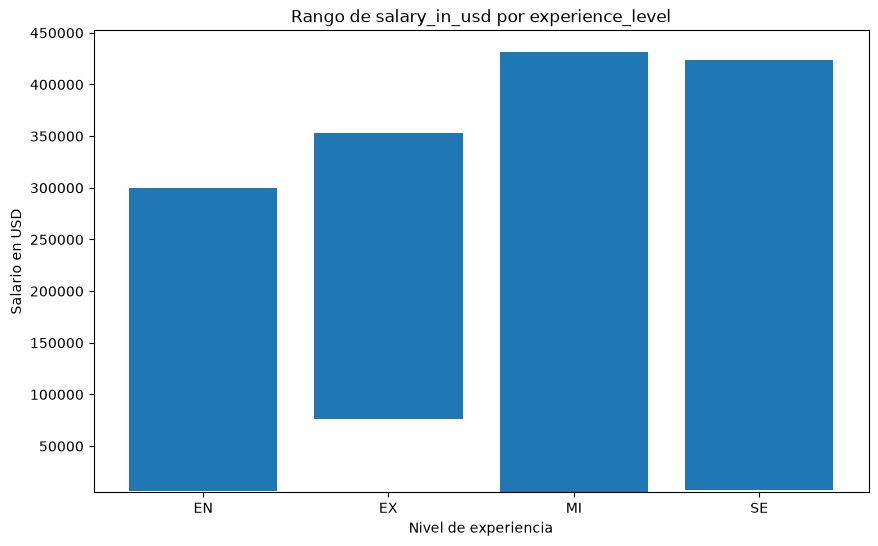

In [37]:
rango = df_actual.groupby("experience_level")["salary_in_usd"].agg(["min", "max"])
rango["rango"] = rango["max"] - rango["min"]

plt.figure(figsize=(10, 6))
plt.bar(rango.index, rango["rango"], bottom=rango["min"])
plt.title("Rango de salary_in_usd por experience_level")
plt.xlabel("Nivel de experiencia")
plt.ylabel("Salario en USD")
plt.show()

## Calidad y drift

En base a lo obtenido en el notebook de actividad 1 tomamos como variables relevantes salary_in_usd, company_location, experience_level, employee_residence.

Además se incluyen las recomendadas en la consigna remote_ratio, company_size

### Calidad

Vamos a validar completitud, unicidad, validez y consistencia ya que el dataset no contiene datos para realizar timeliness


In [9]:
import great_expectations as gx

In [41]:
# Definimos el contexto de Great Expectations

context = gx.get_context()
data_source = context.data_sources.add_pandas("pandas_source") # Le aviso que voy a trabajar con formato de pandas
data_asset = data_source.add_dataframe_asset(name="salaries_asset") # Defino un asset - un dataset
batch_definition = data_asset.add_batch_definition_whole_dataframe("batch_def") # Cada vez que se pida un batch de este dataset, que se tome todo el dataset
batch = batch_definition.get_batch(batch_parameters={"dataframe": df_actual}) # Crear el batch

#### Chequeo de completitud

In [30]:
#1. Completitud

#Columna salary_in_usd
print("Nulos salary_in_usd:")
tasa_nulos_original= df_referencia["salary_in_usd"].isna().sum() / len(df_referencia) * 100
tasa_nulos_actual = df_actual["salary_in_usd"].isna().sum() / len(df_referencia) * 100
print(f"Tasa de nulos original: {tasa_nulos_original:.1f}%")
print(f"Tasa de nulos actual: {tasa_nulos_actual:.1f}%")

#Ejecuto el check
resultado_completitud = batch.validate(
    gx.expectations.ExpectColumnValuesToNotBeNull(column="salary_in_usd", mostly=0.90)
)
print(f"Completitud (salary_in_usd): {'OK' if resultado_completitud.success else 'FAIL'}\n")

#Columna employee_residence
print("Nulos employee_residence:")
tasa_nulos_original= df_referencia["employee_residence"].isna().sum() / len(df_referencia) * 100
tasa_nulos_actual = df_actual["employee_residence"].isna().sum() / len(df_referencia) * 100
print(f"Tasa de nulos original: {tasa_nulos_original:.1f}%")
print(f"Tasa de nulos actual: {tasa_nulos_actual:.1f}%")

#Ejecuto el check
resultado_completitud = batch.validate(
    gx.expectations.ExpectColumnValuesToNotBeNull(column="employee_residence", mostly=0.90)
)
print(f"Completitud (employee_residence): {'OK' if resultado_completitud.success else 'FAIL'}\n")

#Columna experience_level
print("Nulos experience_level:")
tasa_nulos_original= df_referencia["experience_level"].isna().sum() / len(df_referencia) * 100
tasa_nulos_actual = df_actual["experience_level"].isna().sum() / len(df_referencia) * 100
print(f"Tasa de nulos original: {tasa_nulos_original:.1f}%")
print(f"Tasa de nulos actual: {tasa_nulos_actual:.1f}%")

#Ejecuto el check
resultado_completitud = batch.validate(
    gx.expectations.ExpectColumnValuesToNotBeNull(column="experience_level", mostly=0.90)
)
print(f"Completitud (experience_level): {'OK' if resultado_completitud.success else 'FAIL'}\n")

#Columna company_location
print("Nulos company_location:")
tasa_nulos_original= df_referencia["company_location"].isna().sum() / len(df_referencia) * 100
tasa_nulos_actual = df_actual["company_location"].isna().sum() / len(df_referencia) * 100
print(f"Tasa de nulos original: {tasa_nulos_original:.1f}%")
print(f"Tasa de nulos actual: {tasa_nulos_actual:.1f}%")

#Ejecuto el check
resultado_completitud = batch.validate(
    gx.expectations.ExpectColumnValuesToNotBeNull(column="company_location", mostly=0.90)
)
print(f"Completitud (company_location): {'OK' if resultado_completitud.success else 'FAIL'}\n")

#Columna remote_ratio
print("Nulos remote_ratio:")
tasa_nulos_original= df_referencia["remote_ratio"].isna().sum() / len(df_referencia) * 100
tasa_nulos_actual = df_actual["remote_ratio"].isna().sum() / len(df_referencia) * 100
print(f"Tasa de nulos original: {tasa_nulos_original:.1f}%")
print(f"Tasa de nulos actual: {tasa_nulos_actual:.1f}%")

#Ejecuto el check
resultado_completitud = batch.validate(
    gx.expectations.ExpectColumnValuesToNotBeNull(column="remote_ratio", mostly=0.90)
)
print(f"Completitud (remote_ratio): {'OK' if resultado_completitud.success else 'FAIL'}\n")

#Columna company_size
print("Nulos company_size:")
tasa_nulos_original= df_referencia["company_size"].isna().sum() / len(df_referencia) * 100
tasa_nulos_actual = df_actual["company_size"].isna().sum() / len(df_referencia) * 100
print(f"Tasa de nulos original: {tasa_nulos_original:.1f}%")
print(f"Tasa de nulos actual: {tasa_nulos_actual:.1f}%")

#Ejecuto el check
resultado_completitud = batch.validate(
    gx.expectations.ExpectColumnValuesToNotBeNull(column="company_size", mostly=0.90)
)
print(f"Completitud (company_size): {'OK' if resultado_completitud.success else 'FAIL'}\n")


Nulos salary_in_usd:
Tasa de nulos original: 0.0%
Tasa de nulos actual: 0.0%


Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Completitud (salary_in_usd): OK

Nulos employee_residence:
Tasa de nulos original: 0.0%
Tasa de nulos actual: 0.0%


Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Completitud (employee_residence): OK

Nulos experience_level:
Tasa de nulos original: 0.0%
Tasa de nulos actual: 0.0%


...

Completitud (company_location): OK

Nulos remote_ratio:
Tasa de nulos original: 0.0%
Tasa de nulos actual: 0.0%


Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Completitud (remote_ratio): OK

Nulos company_size:
Tasa de nulos original: 0.0%
Tasa de nulos actual: 0.0%


Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Completitud (company_size): OK



#### Chequeo de validez

In [33]:
#2. Validez — estructura/esquema, rango de valores y categorías

resultado_columnas = batch.validate(
    gx.expectations.ExpectTableColumnsToMatchSet(
        column_set=[
            'work_year', 'experience_level', 'employment_type', 'job_title',
            'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
            'remote_ratio', 'company_location', 'company_size'
        ]
    )
)
print(f"Esquema (columnas esperadas): {'OK' if resultado_columnas.success else 'FAIL'}")

#Validez en rango para columnas numéricas

resultado_rango = batch.validate(
    gx.expectations.ExpectColumnValuesToBeBetween(column="salary_in_usd", min_value=4500, max_value=100000)
)
print(f"Validez (salary_in_usd en rango): {'OK' if resultado_rango.success else 'FAIL'} "
      f"({resultado_rango.result['unexpected_count']} valores fuera de rango)")

resultado_rango = batch.validate(
    gx.expectations.ExpectColumnValuesToBeBetween(column="remote_ratio", min_value=0, max_value=100)
)
print(f"Validez (remote_ratio en rango): {'OK' if resultado_rango.success else 'FAIL'} "
      f"({resultado_rango.result['unexpected_count']} valores fuera de rango)")

#Validez en categorías para columnas categóricas
resultado_categorias = batch.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(
        column="experience_level", value_set=['EX', 'MI', 'EN', 'SE']
    )
)
print(f"Validez (categorías de experience_level): {'OK' if resultado_categorias.success else 'FAIL'} "
      f"({resultado_categorias.result['unexpected_count']} categorías no reconocidas)")

resultado_categorias = batch.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(
        column="employee_residence", value_set=['NG', 'US', 'GH', 'SG', 'IN', 'AS', 'AU', 'FR', 'TH', 'GB', 'DK',
                                                'PH', 'PT', 'DE', 'IT', 'CA', 'SI', 'PK', 'HN', 'CZ', 'JP', 'BR',
                                                'VN', 'ES', 'IQ', 'BE', 'GR', 'RU', 'AT', 'UA', 'PL', 'BG', 'HU',
                                                'MX', 'TR', 'NL', 'AE', 'JE', 'PR', 'RS', 'KE', 'CO', 'NZ', 'RO',
                                                'CL', 'HK', 'MD', 'LU', 'HR', 'MT']
    )
)
print(f"Validez (categorías de employee_residence): {'OK' if resultado_categorias.success else 'FAIL'} "
      f"({resultado_categorias.result['unexpected_count']} categorías no reconocidas)")

resultado_categorias = batch.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(
        column="company_location", value_set=['ES', 'US', 'CA', 'DE', 'GB', 'NG', 'IN', 'HK', 'NL', 'CH', 'CF',
                                            'FR', 'FI', 'UA', 'IE', 'IL', 'GH', 'CO', 'SG', 'AU', 'SE', 'SI',
                                            'MX', 'BR', 'PT', 'RU', 'TH', 'HR', 'VN', 'EE', 'AM', 'BA', 'KE',
                                            'GR', 'MK', 'LV', 'RO', 'PK', 'IT', 'MA', 'PL', 'AL', 'AR', 'LT',
                                            'CR', 'IR', 'HU', 'AT', 'SK', 'CZ', 'TR', 'PR', 'AS', 'BO', 'BE',
                                            'ID', 'EG', 'AE', 'LU', 'MY', 'DZ']
    )
)
print(f"Validez (categorías de company_location): {'OK' if resultado_categorias.success else 'FAIL'} "
      f"({resultado_categorias.result['unexpected_count']} categorías no reconocidas)")

resultado_categorias = batch.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(
        column="company_size", value_set=['M', 'S', 'L']
    )
)
print(f"Validez (categorías de company_size): {'OK' if resultado_categorias.success else 'FAIL'} "
      f"({resultado_categorias.result['unexpected_count']} categorías no reconocidas)")


Calculating Metrics:   0%|          | 0/2 [00:00<?, ?it/s]

Esquema (columnas esperadas): OK


Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Validez (salary_in_usd en rango): FAIL (2558 valores fuera de rango)


Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

...

Validez (categorías de employee_residence): FAIL (52 categorías no reconocidas)


Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Validez (categorías de company_location): OK (0 categorías no reconocidas)


Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Validez (categorías de company_size): OK (0 categorías no reconocidas)


#### Chequeo de unicidad

In [34]:
# 3. Unicidad

resultado_unicidad = batch.validate(
    gx.expectations.ExpectCompoundColumnsToBeUnique(
        column_list=['experience_level', 'salary_in_usd', 'employee_residence',
                    'remote_ratio', 'company_location', 'company_size']
    )
)
print(f"Unicidad: {'OK' if resultado_unicidad.success else 'FAIL'} "
      f"({resultado_unicidad.result['unexpected_count']} duplicados)")


Calculating Metrics:   0%|          | 0/9 [00:00<?, ?it/s]

Unicidad: FAIL (2443 duplicados)


#### Chequeo de consistencia

In [42]:
#4. Consistencia

df_actual["diferencia_salario"] = (df_actual["salary"] - df_actual["salary_in_usd"]).abs()
df_usd = df_actual[df_actual["salary_currency"] == "USD"]

data_asset_2 = data_source.add_dataframe_asset(name="salaries_consistencia")
batch_def_2 = data_asset_2.add_batch_definition_whole_dataframe("batch_def_2")
batch_2 = batch_def_2.get_batch(batch_parameters={"dataframe": df_usd})

resultado_consistencia = batch_2.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(column="diferencia_salario", value_set=[0])
)
print(f"Consistencia (salary == salary_in_usd cuando currency=USD): {'OK' if resultado_consistencia.success else 'FAIL'}")

df_presencial = df_actual[df_actual["remote_ratio"] == 0].copy()
df_presencial["coincide_ubicacion"] = (df_presencial["employee_residence"] == df_presencial["company_location"]).astype(int)

data_asset_3 = data_source.add_dataframe_asset(name="salaries_consistencia_2")
batch_def_3 = data_asset_3.add_batch_definition_whole_dataframe("batch_def_3")
batch_3 = batch_def_3.get_batch(batch_parameters={"dataframe": df_presencial})

resultado_consistencia_2 = batch_3.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(column="coincide_ubicacion", value_set=[1], mostly=0.90)
)
print(f"Consistencia (residencia == ubicación empresa cuando remote_ratio=0): {'OK' if resultado_consistencia_2.success else 'FAIL'}")



Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Consistencia (salary == salary_in_usd cuando currency=USD): OK


Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Consistencia (residencia == ubicación empresa cuando remote_ratio=0): OK


In [40]:
orden_esperado = ['EN', 'MI', 'SE', 'EX']  # de menor a mayor experiencia

medianas = df_actual.groupby('experience_level')['salary_in_usd'].median().reindex(orden_esperado)
print("Mediana de salary_in_usd por experience_level:")
print(medianas)

es_monotona = medianas.is_monotonic_increasing
print(f"\nConsistencia (mediana de salario aumenta con la experiencia): {'OK' if es_monotona else 'FAIL'}")

if not es_monotona:
    diffs = medianas.diff()
    inversiones = diffs[diffs < 0]
    print(f"Inversiones detectadas en: {list(inversiones.index)}")


Mediana de salary_in_usd por experience_level:
experience_level
EN     75000.0
MI    100000.0
SE    147100.0
EX    200000.0
Name: salary_in_usd, dtype: float64

Consistencia (mediana de salario aumenta con la experiencia): OK


In [48]:
df_actual=df_actual.drop(["diferencia_salario"], axis=1)

#### Conclusiones chequeo de calidad

En los chequeos de calidad se puede observar que el dataset está completo no tiene valores nulos en las variables que se utilizaron. Esto es consistente con el pequeño EDA realizado anteriormente.

Con respecto a la validez, se ve que no hay ninguna columna de más producto de que se está simulando dos datasets a partir de uno. Como se estableció un rango menor para la variable salary_in_usd se detectaron 2558 valores fuera de rango. Además para el caso de la variable  employee_residence se obtuvo un resultado de 52 categorías no reconocidas ya que se tomaron los valores del dataset de referencia. Esto muestra que para las categorías de dataset de referencia (2020 y 2021) no coinciden con el dataset actual lo que demuestra que hubo un cambio en la toma de datos. El resto de las variables dieron OK.

En cuanto a unicidad, se compararon las 6 variables elegidas y se obtuvieron 2443 duplicados. A mi criterio es raro que más de una persona coincida en todas las variables, por lo general al menos en salario debería haber diferencia aunque el resto de variables coincidan, teniendo en cuenta el rango de salarios para cada nivel de experiencia que se puede visualizar en el gráfico.

Por último se validó consistencia para ver si coincidían las variables salary y salary_in_usd  en aquellos casos donde salary_currency estuviera determinada como USD. También se validó que coincidiera la localización de la empresa con la residencia de los empleados en los casos donde fuera trabajo presencial (remote_ratio=0). Y agregué al final una validación que si bien no se hace con la librería que venía utilizando, me interesaba saber si el salario era consistente con el nivel de experiencia ya que en el gráfico "Rango de salary_in_usd por experience_level" hay algunos de SE que tienen un sueldo mayor que EX, con esto pude confirmar que seguramente son outliers, debería continuar profundizando en ese análisis.

### PSI

In [ ]:
remote_ratio, company_size
salary_in_usd, company_location, experience_level, employee_residence

In [52]:
# Primero instancio los datasets en Evidently a partir del dataframe con el dataset actual y el dataset de referencia
ref_dataset = Dataset.from_pandas(df_referencia, data_definition=DataDefinition())
actual_dataset = Dataset.from_pandas(df_actual, data_definition=DataDefinition())

# Defino un reporte con los métodos que quiero
report_psi = Report(metrics=[
    ValueDrift(column="company_location", method="psi", threshold=0.25),
    ValueDrift(column="salary_in_usd", method="psi", threshold=0.25),
    ValueDrift(column="experience_level", method="psi", threshold=0.25),
    ValueDrift(column="employee_residence", method="psi", threshold=0.25),
    ValueDrift(column="remote_ratio", method="psi", threshold=0.25),
    ValueDrift(column="company_size", method="psi", threshold=0.25),
])

# Corro el reporte con los datasets que instancié
resultado_psi = report_psi.run(actual_dataset, ref_dataset)

for m in resultado_psi.dict()["metrics"]:
    print(m["metric_name"], "->", round(m["value"], 4))

ValueDrift(column=company_location,method=psi,threshold=0.25) -> 1.2761
ValueDrift(column=salary_in_usd,method=psi,threshold=0.25) -> 0.9204
ValueDrift(column=experience_level,method=psi,threshold=0.25) -> 0.7417
ValueDrift(column=employee_residence,method=psi,threshold=0.25) -> 1.5217
ValueDrift(column=remote_ratio,method=psi,threshold=0.25) -> 1.1914
ValueDrift(column=company_size,method=psi,threshold=0.25) -> 2.1981


Se estableció como valor de umbral 0.25 ya que es el utilizado por convención.

Si tomamos como target la variable salary_in_usd y como features las demás variables podemos decir que:
- para las features se observa que todas tienen covariate shift ya que el valor de psi es mayor al umbral de 0.25 establecido
- para la target se ve que tiene label shift ya que el valor de psi es mayor al umbral establecido

A continuación se evalua la relación entre las features y la target para determinar si alguna presenta concept drift

In [58]:
features = ['experience_level', 'company_location', 'employee_residence', 'remote_ratio', 'company_size']

for feature in features:
    medianas_ref = df_referencia.groupby(feature)['salary_in_usd'].median()
    medianas_actual = df_actual.groupby(feature)['salary_in_usd'].median()
    n_ref = df_referencia.groupby(feature)['salary_in_usd'].count()
    n_actual = df_actual.groupby(feature)['salary_in_usd'].count()

    comparacion = pd.DataFrame({
        'referencia': medianas_ref,
        'actual': medianas_actual,
        'n_referencia': n_ref,
        'n_actual': n_actual,
    })
    comparacion['variacion_%'] = (comparacion['actual'] - comparacion['referencia']) / comparacion['referencia'] * 100

    # Filtramos categorías con pocas muestras en alguno de los dos datasets (poco confiables)
    comparacion_filtrada = comparacion[(comparacion['n_referencia'] >= 5) & (comparacion['n_actual'] >= 5)]

    print(f"\n=== {feature} ===")
    print(comparacion_filtrada.sort_values('variacion_%'))
    print(f"Dispersión de la variación entre categorías (std): {comparacion_filtrada['variacion_%'].std():.1f}%")



=== experience_level ===
                  referencia    actual  n_referencia  n_actual  variacion_%
experience_level                                                           
SE                  120000.0  147100.0            91      2425    22.583333
EX                  150000.0  200000.0            13       101    33.333333
MI                   74065.0  100000.0           124       681    35.016540
EN                   49823.0   75000.0            78       242    50.532886
Dispersión de la variación entre categorías (std): 11.5%

=== company_location ===
                  referencia    actual  n_referencia  n_actual  variacion_%
company_location                                                           
DE                   76833.0   69751.0          23.0      33.0    -9.217394
IN                   19804.5   18021.5          26.0      32.0    -9.003004
GB                   82528.0   78990.0          19.0     153.0    -4.287030
ES                   47045.5   47280.0           8.0   

Ajustamos el n para la variable employee_residence 

In [57]:
feature="employee_residence"
medianas_ref = df_referencia.groupby(feature)['salary_in_usd'].median()
medianas_actual = df_actual.groupby(feature)['salary_in_usd'].median()
n_ref = df_referencia.groupby(feature)['salary_in_usd'].count()
n_actual = df_actual.groupby(feature)['salary_in_usd'].count()

comparacion = pd.DataFrame({
    'referencia': medianas_ref,
    'actual': medianas_actual,
    'n_referencia': n_ref,
    'n_actual': n_actual,
})
comparacion['variacion_%'] = (comparacion['actual'] - comparacion['referencia']) / comparacion['referencia'] * 100

# Filtramos categorías con pocas muestras en alguno de los dos datasets (poco confiables)
comparacion_filtrada = comparacion[(comparacion['n_referencia'] >= 15) & (comparacion['n_actual'] >= 15)]

print(f"\n=== {feature} ===")
print(comparacion_filtrada.sort_values('variacion_%'))
print(f"Dispersión de la variación entre categorías (std): {comparacion_filtrada['variacion_%'].std():.1f}%")


=== employee_residence ===
                    referencia    actual  n_referencia  n_actual  variacion_%
employee_residence                                                           
DE                     78015.0   74597.0          22.0      26.0    -4.381209
GB                     82528.0   78990.0          16.0     151.0    -4.287030
US                    135000.0  145000.0         114.0    2890.0     7.407407
IN                     19609.0   21938.0          31.0      40.0    11.877199
FR                     52256.5   64763.0          16.0      22.0    23.932908
Dispersión de la variación entre categorías (std): 11.9%


Como conclusión podemos decir que las variables que más determinan concept drift son remote_ratio y company_size ya que se observa una gran variación entre el dataset de referencia y el actual con respecto a la relación con la target.

En segundo lugar podemos mencionar a company_location y employee_residence ya que muestran reconfiguración global en localización.

En cuanto a experience_level si bien aumenta más en niveles más bajos que los senior la variación es consistente por lo cual podríamos decir que no presenta concept drift

Reporte completo

In [59]:
reporte_completo = Report(metrics=[DataDriftPreset()])
resultado_completo = reporte_completo.run(actual_dataset, ref_dataset)

ruta_reporte = os.path.join("..", "data", "resultado_completo.html")
resultado_completo.save_html(ruta_reporte)

Con respecto al modelo entrenado en la actividad 1 la estrategia que aplicaría es reentrenamiento por las variables que presentan concept drift para corregirlo (remote_ratio y company_size) y feature engineering por las variables que mostraron covariate y label shift para evitar que vuelva a suceder (experience_level, company_location, employee_residence, salary_in_usd).